# Single-Step Fragment Matching

This notebook checks one narrow question: for a fixed `CH2` fragment, what does the current symmetry-compressed elementary matcher return when the product target has more hydrogens than the fragment consumes?

The notebook intentionally exposes the middle process. Each important stage is a separate cell:

1. generate a target molecule with RDKit
2. build the fragment and target WBO graphs
3. compute orbit labels
4. anchor the fragment carbon
5. call `_extend_sym_cands` for the first H
6. call `_extend_sym_cands` for the second H

RDKit is used only to create chemically valid example molecules and a simple bond-order matrix. No XTB and no full molecule alignment pipeline are used here.

Note: neutral `R-CH4` is not a chemically valid carbon valence pattern in RDKit. The chemically valid version of the same boundary question is a `CH2` fragment matching into a methyl group in ethane, `R-CH3`: the target carbon has an outside substituent that is not part of the fragment.


In [1]:
from pathlib import Path
import math
import sys

import numpy as np
from IPython.display import Markdown, display
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

repo = Path.cwd()
if repo.name == "notebooks":
    repo = repo.parent
sys.path.insert(0, str(repo / "src"))

from rxn_core import build_graph
from rxn_core.matcher import (
    _SymCand,
    _cand_map,
    _cand_possible_p_atoms,
    _nauty_orbits,
    _extend_sym_cands,
)


## Small helpers only

These helpers do not run matching. They only create RDKit molecules, convert them to `(elements, xyz, wbo)`, format candidates, and count represented injective assignments.


In [2]:
def mol_from_smiles(smiles, seed=7):
    mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
    status = AllChem.EmbedMolecule(mol, randomSeed=seed)
    if status != 0:
        raise RuntimeError(f"RDKit embedding failed for {smiles}")
    AllChem.UFFOptimizeMolecule(mol)
    return mol


def arrays_from_mol(mol):
    elements = [atom.GetSymbol() for atom in mol.GetAtoms()]
    conf = mol.GetConformer()
    xyz = np.array([
        [conf.GetAtomPosition(i).x, conf.GetAtomPosition(i).y, conf.GetAtomPosition(i).z]
        for i in range(mol.GetNumAtoms())
    ])
    wbo = np.zeros((mol.GetNumAtoms(), mol.GetNumAtoms()))
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        value = float(bond.GetBondTypeAsDouble())
        wbo[i, j] = value
        wbo[j, i] = value
    return elements, xyz, wbo


def carbon_hydrogens(mol, carbon_idx):
    atom = mol.GetAtomWithIdx(carbon_idx)
    assert atom.GetSymbol() == "C"
    return [nbr.GetIdx() for nbr in atom.GetNeighbors() if nbr.GetSymbol() == "H"]


def subfragment(elements, xyz, wbo, atom_ids):
    atom_ids = list(atom_ids)
    return (
        [elements[i] for i in atom_ids],
        xyz[atom_ids],
        wbo[np.ix_(atom_ids, atom_ids)],
    )


def represented_count(cand):
    count = cand.multiplicity
    for block in cand.blocks:
        n = len(block.p_atoms)
        k = len(block.r_atoms)
        count *= math.factorial(n) // math.factorial(n - k)
    return count


def describe_cands(cands):
    rows = []
    for cand in cands:
        rows.append({
            "witness": dict(sorted(_cand_map(cand).items())),
            "blocks": [
                {
                    "R_atoms": tuple(block.r_atoms),
                    "P_pool": tuple(block.p_atoms),
                    "extendable": block.extendable,
                }
                for block in cand.blocks
            ],
            "possible_P_atoms": tuple(sorted(_cand_possible_p_atoms(cand))),
            "multiplicity": cand.multiplicity,
            "represented": represented_count(cand),
        })
    return rows


def print_stage(title, cands):
    print("\n" + title)
    print("compressed candidate count:", len(cands))
    for i, row in enumerate(describe_cands(cands)):
        print(f"candidate {i}")
        print("  witness:", row["witness"])
        print("  blocks:", row["blocks"])
        print("  possible_P_atoms:", row["possible_P_atoms"])
        print("  represented concrete assignments:", row["represented"])


## Targets

`CH4` tests `CH2` matching into four equivalent hydrogens. Ethane tests `CH2` matching into a methyl group that has an outside carbon substituent.


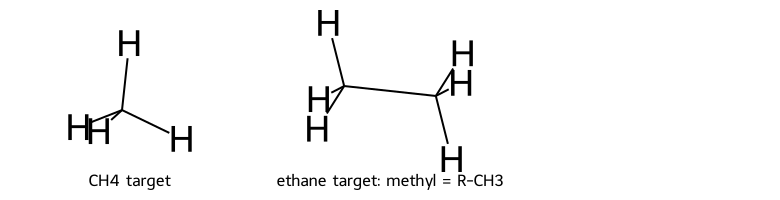

In [3]:
methane = mol_from_smiles("C")
ethane = mol_from_smiles("CC")

display(Draw.MolsToGridImage(
    [methane, ethane],
    legends=["CH4 target", "ethane target: methyl = R-CH3"],
    subImgSize=(260, 200),
))


# Case 1: `CH2` fragment into `CH4`

We choose the methane carbon as the anchored carbon. The fragment is the target carbon plus two of its hydrogens, in local fragment order `[C, H, H]`.


In [4]:
elements_P_ch4, xyz_P_ch4, wbo_P_ch4 = arrays_from_mol(methane)
target_carbon_ch4 = 0
target_Hs_ch4 = carbon_hydrogens(methane, target_carbon_ch4)
fragment_ids_ch4 = [target_carbon_ch4] + target_Hs_ch4[:2]
elements_R_ch4, xyz_R_ch4, wbo_R_ch4 = subfragment(
    elements_P_ch4, xyz_P_ch4, wbo_P_ch4, fragment_ids_ch4,
)

print("target elements:", list(enumerate(elements_P_ch4)))
print("target carbon:", target_carbon_ch4)
print("target hydrogens:", target_Hs_ch4)
print("fragment atom ids in target:", fragment_ids_ch4)
print("fragment elements:", elements_R_ch4)
print("fragment WBO matrix:\n", wbo_R_ch4)


target elements: [(0, 'C'), (1, 'H'), (2, 'H'), (3, 'H'), (4, 'H')]
target carbon: 0
target hydrogens: [1, 2, 3, 4]
fragment atom ids in target: [0, 1, 2]
fragment elements: ['C', 'H', 'H']
fragment WBO matrix:
 [[0. 1. 1.]
 [1. 0. 0.]
 [1. 0. 0.]]


Build the WBO graphs and orbit labels. The target hydrogens should share one orbit in methane.


In [5]:
g_R_ch4 = build_graph(elements_R_ch4, wbo_R_ch4, bond_cut=0.2)
g_P_ch4 = build_graph(elements_P_ch4, wbo_P_ch4, bond_cut=0.2)
r_orbits_ch4 = _nauty_orbits(g_R_ch4, wbo_tol=0.2)
p_orbits_ch4 = _nauty_orbits(g_P_ch4, wbo_tol=0.2)

print("R fragment orbits:", r_orbits_ch4)
print("P target orbits:", p_orbits_ch4)
print("P H orbit ids:", {h: p_orbits_ch4[h] for h in target_Hs_ch4})


R fragment orbits: {0: 0, 1: 1, 2: 1}
P target orbits: {0: 0, 1: 1, 2: 1, 3: 1, 4: 1}
P H orbit ids: {1: 1, 2: 1, 3: 1, 4: 1}


Start from one anchored candidate: fragment carbon `R[0]` maps to target carbon `P[0]`.


In [6]:
cands_ch4_0 = [_SymCand({0: target_carbon_ch4})]
print_stage("CH4 anchor: F = {C}", cands_ch4_0)



CH4 anchor: F = {C}
compressed candidate count: 1
candidate 0
  witness: {0: 0}
  blocks: []
  possible_P_atoms: (0,)
  represented concrete assignments: 1


Extend the fragment by the first hydrogen. This is the elementary call `F -> F + H1`. Because all four target hydrogens are equivalent, one symmetry block is created.


In [7]:
cands_ch4_1 = _extend_sym_cands(
    cands_ch4_0,
    {0},
    1,
    g_R_ch4,
    g_P_ch4,
    {},
    0.5,
    None,
    p_orbits=p_orbits_ch4,
    r_orbits=r_orbits_ch4,
    anchor_u=0,
    anchor_wbo=wbo_R_ch4[0, 1],
)
print_stage("CH4 after H1: F = {C,H1}", cands_ch4_1)
assert len(cands_ch4_1) == 1
assert represented_count(cands_ch4_1[0]) == 4



CH4 after H1: F = {C,H1}
compressed candidate count: 1
candidate 0
  witness: {0: 0, 1: 1}
  blocks: [{'R_atoms': (1,), 'P_pool': (1, 2, 3, 4), 'extendable': True}]
  possible_P_atoms: (0, 1, 2, 3, 4)
  represented concrete assignments: 4


Extend by the second hydrogen. The existing H block should expand from one R hydrogen to two R hydrogens occupying the four target H atoms.


In [8]:
cands_ch4_2 = _extend_sym_cands(
    cands_ch4_1,
    {0, 1},
    2,
    g_R_ch4,
    g_P_ch4,
    {},
    0.5,
    None,
    p_orbits=p_orbits_ch4,
    r_orbits=r_orbits_ch4,
    anchor_u=0,
    anchor_wbo=wbo_R_ch4[0, 2],
)
print_stage("CH4 after H2: F = {C,H1,H2}", cands_ch4_2)
assert len(cands_ch4_2) == 1
assert represented_count(cands_ch4_2[0]) == 12



CH4 after H2: F = {C,H1,H2}
compressed candidate count: 1
candidate 0
  witness: {0: 0, 1: 2, 2: 1}
  blocks: [{'R_atoms': (1, 2), 'P_pool': (1, 2, 3, 4), 'extendable': True}]
  possible_P_atoms: (0, 1, 2, 3, 4)
  represented concrete assignments: 12


# Case 2: `CH2` fragment into ethane methyl (`R-CH3`)

This is the chemically valid analogue of `R-CH4`. The matched fragment only includes the methyl carbon and two hydrogens. The other carbon is outside the fragment.


In [9]:
elements_P_ethane, xyz_P_ethane, wbo_P_ethane = arrays_from_mol(ethane)
target_carbon_ethane = 0
target_Hs_ethane = carbon_hydrogens(ethane, target_carbon_ethane)
fragment_ids_ethane = [target_carbon_ethane] + target_Hs_ethane[:2]
elements_R_ethane, xyz_R_ethane, wbo_R_ethane = subfragment(
    elements_P_ethane, xyz_P_ethane, wbo_P_ethane, fragment_ids_ethane,
)

print("target elements:", list(enumerate(elements_P_ethane)))
print("target carbon:", target_carbon_ethane)
print("outside substituent atom:", 1)
print("target hydrogens on matched carbon:", target_Hs_ethane)
print("fragment atom ids in target:", fragment_ids_ethane)
print("fragment elements:", elements_R_ethane)
print("fragment WBO matrix:\n", wbo_R_ethane)
print("target carbon outside C WBO:", wbo_P_ethane[target_carbon_ethane, 1])


target elements: [(0, 'C'), (1, 'C'), (2, 'H'), (3, 'H'), (4, 'H'), (5, 'H'), (6, 'H'), (7, 'H')]
target carbon: 0
outside substituent atom: 1
target hydrogens on matched carbon: [2, 3, 4]
fragment atom ids in target: [0, 2, 3]
fragment elements: ['C', 'H', 'H']
fragment WBO matrix:
 [[0. 1. 1.]
 [1. 0. 0.]
 [1. 0. 0.]]
target carbon outside C WBO: 1.0


Build WBO graphs and orbit labels for the ethane case. The three hydrogens on the matched methyl carbon form a local target pool for this anchored fragment.


In [10]:
g_R_ethane = build_graph(elements_R_ethane, wbo_R_ethane, bond_cut=0.2)
g_P_ethane = build_graph(elements_P_ethane, wbo_P_ethane, bond_cut=0.2)
r_orbits_ethane = _nauty_orbits(g_R_ethane, wbo_tol=0.2)
p_orbits_ethane = _nauty_orbits(g_P_ethane, wbo_tol=0.2)

print("R fragment orbits:", r_orbits_ethane)
print("P target orbits:", p_orbits_ethane)
print("P H orbit ids on matched carbon:", {h: p_orbits_ethane[h] for h in target_Hs_ethane})


R fragment orbits: {0: 0, 1: 1, 2: 1}
P target orbits: {0: 0, 1: 0, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1}
P H orbit ids on matched carbon: {2: 1, 3: 1, 4: 1}


Start from the same kind of anchored candidate: fragment carbon `R[0]` maps to ethane target carbon `P[0]`.


In [11]:
cands_ethane_0 = [_SymCand({0: target_carbon_ethane})]
print_stage("ethane anchor: F = {C}", cands_ethane_0)



ethane anchor: F = {C}
compressed candidate count: 1
candidate 0
  witness: {0: 0}
  blocks: []
  possible_P_atoms: (0,)
  represented concrete assignments: 1


Extend by the first hydrogen. The target pool is the three hydrogens on the anchored methyl carbon, not the hydrogens on the other methyl group, because the WBO vector to the anchored carbon must match.


In [12]:
cands_ethane_1 = _extend_sym_cands(
    cands_ethane_0,
    {0},
    1,
    g_R_ethane,
    g_P_ethane,
    {},
    0.5,
    None,
    p_orbits=p_orbits_ethane,
    r_orbits=r_orbits_ethane,
    anchor_u=0,
    anchor_wbo=wbo_R_ethane[0, 1],
)
print_stage("ethane after H1: F = {C,H1}", cands_ethane_1)
assert len(cands_ethane_1) == 1
assert represented_count(cands_ethane_1[0]) == 3



ethane after H1: F = {C,H1}
compressed candidate count: 1
candidate 0
  witness: {0: 0, 1: 2}
  blocks: [{'R_atoms': (1,), 'P_pool': (2, 3, 4), 'extendable': True}]
  possible_P_atoms: (0, 2, 3, 4)
  represented concrete assignments: 3


Extend by the second hydrogen. Two fragment hydrogens now inject into the three hydrogens on the anchored methyl carbon, so the compact state represents `P(3,2) = 6` concrete assignments.


In [13]:
cands_ethane_2 = _extend_sym_cands(
    cands_ethane_1,
    {0, 1},
    2,
    g_R_ethane,
    g_P_ethane,
    {},
    0.5,
    None,
    p_orbits=p_orbits_ethane,
    r_orbits=r_orbits_ethane,
    anchor_u=0,
    anchor_wbo=wbo_R_ethane[0, 2],
)
print_stage("ethane after H2: F = {C,H1,H2}", cands_ethane_2)
assert len(cands_ethane_2) == 1
assert represented_count(cands_ethane_2[0]) == 6



ethane after H2: F = {C,H1,H2}
compressed candidate count: 1
candidate 0
  witness: {0: 0, 1: 3, 2: 2}
  blocks: [{'R_atoms': (1, 2), 'P_pool': (2, 3, 4), 'extendable': True}]
  possible_P_atoms: (0, 2, 3, 4)
  represented concrete assignments: 6


## Summary

The elementary matcher returns canonical compressed candidates, not all concrete bijections.


In [14]:
summary_rows = [
    ("CH2 -> CH4", len(cands_ch4_2), represented_count(cands_ch4_2[0]), describe_cands(cands_ch4_2)[0]["blocks"]),
    ("CH2 -> ethane methyl (R-CH3)", len(cands_ethane_2), represented_count(cands_ethane_2[0]), describe_cands(cands_ethane_2)[0]["blocks"]),
]

lines = ["| case | compressed candidates | represented assignments | symmetry block |", "|---|---:|---:|---|"]
for label, n_cands, represented, blocks in summary_rows:
    lines.append(f"| {label} | {n_cands} | {represented} | `{blocks}` |")
display(Markdown("\n".join(lines)))


| case | compressed candidates | represented assignments | symmetry block |
|---|---:|---:|---|
| CH2 -> CH4 | 1 | 12 | `[{'R_atoms': (1, 2), 'P_pool': (1, 2, 3, 4), 'extendable': True}]` |
| CH2 -> ethane methyl (R-CH3) | 1 | 6 | `[{'R_atoms': (1, 2), 'P_pool': (2, 3, 4), 'extendable': True}]` |

## Interpretation

Current behavior is symmetry-compressed and injective:

- `CH2 -> CH4` gives one compressed candidate with a block saying two fragment hydrogens occupy the four target hydrogens. That represents `P(4,2) = 12` concrete injective assignments.
- `CH2 -> R-CH3` gives one compressed candidate with a block saying two fragment hydrogens occupy the three methyl hydrogens. That represents `P(3,2) = 6` concrete injective assignments.
- The outside `R` substituent in ethane does not invalidate the fragment match because the matched fragment only checks WBO relationships among atoms inside the fragment.
